In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

In [2]:
df = pd.read_csv("../data/city_lifestyle_dataset.csv")

print(df.head())
print(df.shape)

       city_name country  population_density  avg_income  \
0      Old Vista  Europe                2775        3850   
1      Beachport  Europe                3861        3700   
2  Valleyborough  Europe                2562        4310   
3           City  Europe                3192        3970   
4          Falls  Europe                3496        4320   

   internet_penetration  avg_rent  air_quality_index  public_transport_score  \
0                  86.4      1310                 43                    52.0   
1                  78.1      1330                 42                    62.8   
2                  80.1      1330                 39                    73.2   
3                  81.2      1480                 60                    49.2   
4                 100.0      1510                 64                    93.7   

   happiness_score  green_space_ratio  
0              8.5               23.8  
1              8.1               33.1  
2              8.5               40.2 

In [3]:
X = df.drop(["city_name", "country"], axis=1)
X.head()

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,3496,4320,100.0,1510,64,93.7,8.5,42.5


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

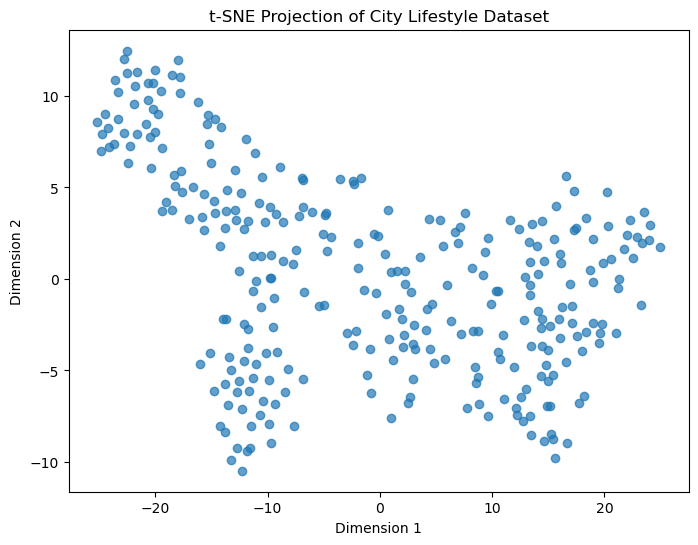

In [6]:
plt.figure(figsize=(8,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], alpha=0.7)
plt.title("t-SNE Projection of City Lifestyle Dataset")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()

# Interprétation de la projection

La projection t-SNE met en évidence plusieurs groupes distincts de villes dans l’espace réduit en deux dimensions. On observe au moins trois à quatre clusters relativement denses, ce qui suggère que les villes s’organisent naturellement en différents profils de style de vie en fonction des variables économiques, environnementales et sociales.

Certains groupes sont clairement séparés (notamment ceux situés à gauche et à droite du graphique), indiquant des différences marquées entre certaines catégories de villes, probablement liées au niveau de revenu, à la densité de population, à la qualité de l’air ou encore aux infrastructures.

La structure courbée et non linéaire observée confirme que les relations entre les variables ne sont pas strictement linéaires. La méthode t-SNE, qui préserve les voisinages locaux, permet de mieux révéler ces structures complexes que des méthodes linéaires comme la PCA.
Dans l’ensemble, la visualisation suggère que le jeu de données possède une structure latente cohérente et exploitable pour une analyse par clustering ou segmentation des villes.